# 🛂 Visa Application Risk Assessment: ML for Immigration Decision Support

**Author:** Dean | Lead Data & AI Engineer  
**Focus:** Predicting visa application outcomes to support immigration processing efficiency and compliance  
**Series:** Production ML Portfolio — Australian Government Policy Applications

---

## Executive Summary

This notebook demonstrates a production-grade ML pipeline for predicting visa application outcomes using applicant qualifications, employer characteristics, and labour market indicators. The model supports **application triage**, **processing prioritisation**, and **compliance risk screening**.

### Government Policy Context
- **Home Affairs** — Visa processing, migration program planning, integrity and compliance
- **ABF (Australian Border Force)** — Border risk assessment, visa overstay prediction
- **Department of Employment** — Labour market testing, skills shortage lists (PMSOL, MLTSSL)
- **Fair Work Ombudsman** — Visa holder worker exploitation monitoring
- **Migration Institute of Australia** — Professional standards for migration agents

### Operational Decision Framework
| Prediction | Action | Stakeholder |
|-----------|--------|-------------|
| High approval likelihood | Fast-track processing stream | Visa processing officer |
| Moderate likelihood | Standard assessment, may need additional docs | Case officer |
| Low likelihood (risk flags) | Enhanced scrutiny, integrity check referral | Compliance team |
| High refusal risk | Priority review, potential employer audit | ABF intelligence |

### Ethical Considerations
Visa decisions profoundly impact people's lives. ML models must never replace human decision-making in immigration. Models serve as decision-support tools only, with full appeal rights preserved. Fairness monitoring across nationality, gender, and age is mandatory.

---


## 1. Data Loading & Initial Assessment

In [1]:
import os, warnings, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (accuracy_score, f1_score, classification_report,
                             confusion_matrix, roc_auc_score, precision_score,
                             recall_score, brier_score_loss)
from sklearn.calibration import calibration_curve
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
print("=" * 60)
print("ENVIRONMENT READY")
print("=" * 60)


ENVIRONMENT READY


In [2]:
data_path = None
all_files = []
print("Scanning /kaggle/input...")
for root, dirs, files in os.walk('/kaggle/input'):
    for f in files:
        full_path = os.path.join(root, f)
        print(f"  Found: {full_path}")
        if f.endswith('.csv'):
            all_files.append(full_path)
        elif f.endswith('.xlsx'):
            all_files.append(full_path)

csv_files = [f for f in all_files if f.endswith('.csv')]
xlsx_files = [f for f in all_files if f.endswith('.xlsx')]

if csv_files:
    sizes = {p: os.path.getsize(p) for p in csv_files}
    data_path = max(sizes, key=sizes.get)
    with open(data_path, 'r') as fh:
        sample = fh.read(2048)
    sep = ';' if sample.count(';') > sample.count(',') else ','
    df = pd.read_csv(data_path, sep=sep)
elif xlsx_files:
    sizes = {p: os.path.getsize(p) for p in xlsx_files}
    data_path = max(sizes, key=sizes.get)
    df = pd.read_excel(data_path)
else:
    raise FileNotFoundError("No CSV or XLSX found")

print(f"\nUsing: {data_path}")
print(f"Loaded: {df.shape[0]:,} rows x {df.shape[1]} columns")


Scanning /kaggle/input...
  Found: /kaggle/input/datasets/moro23/easyvisa-dataset/EasyVisa.csv

Using: /kaggle/input/datasets/moro23/easyvisa-dataset/EasyVisa.csv
Loaded: 25,480 rows x 12 columns


In [3]:
print("COLUMN SUMMARY")
print("=" * 80)
for i, col in enumerate(df.columns):
    dtype = df[col].dtype
    nuniq = df[col].nunique()
    nulls = df[col].isnull().sum()
    sample_val = df[col].dropna().iloc[0] if len(df[col].dropna()) > 0 else 'N/A'
    print(f"  {i:2d}. {col:35s} | {str(dtype):10s} | unique={nuniq:6d} | nulls={nulls:3d} | eg: {sample_val}")
df.head()


COLUMN SUMMARY
   0. case_id                             | object     | unique= 25480 | nulls=  0 | eg: EZYV01
   1. continent                           | object     | unique=     6 | nulls=  0 | eg: Asia
   2. education_of_employee               | object     | unique=     4 | nulls=  0 | eg: High School
   3. has_job_experience                  | object     | unique=     2 | nulls=  0 | eg: N
   4. requires_job_training               | object     | unique=     2 | nulls=  0 | eg: N
   5. no_of_employees                     | int64      | unique=  7105 | nulls=  0 | eg: 14513
   6. yr_of_estab                         | int64      | unique=   199 | nulls=  0 | eg: 2007
   7. region_of_employment                | object     | unique=     5 | nulls=  0 | eg: West
   8. prevailing_wage                     | float64    | unique= 25454 | nulls=  0 | eg: 592.2029
   9. unit_of_wage                        | object     | unique=     4 | nulls=  0 | eg: Hour
  10. full_time_position             

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,Certified
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,Denied
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,Denied
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,149907.3900,Year,Y,Certified


## 2. Target Variable Identification & Analysis

In [4]:
target_candidates = ['case_status', 'Case_Status', 'status', 'Status', 'visa_status',
                     'decision', 'Decision', 'outcome', 'Outcome', 'Target', 'target',
                     'Class', 'class', 'Label', 'Certified']
target_col = None
for candidate in target_candidates:
    if candidate in df.columns:
        target_col = candidate
        print(f"Found target: '{target_col}'")
        break

if target_col is None:
    for col in df.columns:
        if df[col].dtype == 'object' and df[col].nunique() == 2:
            vals = [str(v).lower() for v in df[col].unique()]
            if any(kw in v for v in vals for kw in ['certified', 'denied', 'approved', 'rejected']):
                target_col = col
                print(f"Auto-detected: '{target_col}'")
                break

if target_col is None:
    for col in df.columns:
        if df[col].nunique() == 2 and col.lower() not in ['id', 'index']:
            target_col = col
            print(f"Binary fallback: '{target_col}'")
            break

if target_col is None:
    raise ValueError("Could not identify target")

print(f"\nRaw values:")
print(df[target_col].value_counts())

if df[target_col].dtype == 'object':
    denied_kw = ['Denied', 'denied', 'Rejected', 'rejected', 'No', 'N', '0', 'Refused']
    mapping = {v: (1 if v in denied_kw else 0) for v in df[target_col].unique()}
    df[target_col] = df[target_col].map(mapping)
    print(f"Mapped (1=Denied/Refused, 0=Certified/Approved): {mapping}")

print(f"\nDistribution:")
print(df[target_col].value_counts().sort_index())
assert df[target_col].nunique() >= 2
imbalance_ratio = df[target_col].value_counts().min() / df[target_col].value_counts().max()
print(f"\nImbalance ratio: {imbalance_ratio:.3f}")


Found target: 'case_status'

Raw values:
case_status
Certified    17018
Denied        8462
Name: count, dtype: int64
Mapped (1=Denied/Refused, 0=Certified/Approved): {'Denied': 1, 'Certified': 0}

Distribution:
case_status
0    17018
1     8462
Name: count, dtype: int64

Imbalance ratio: 0.497


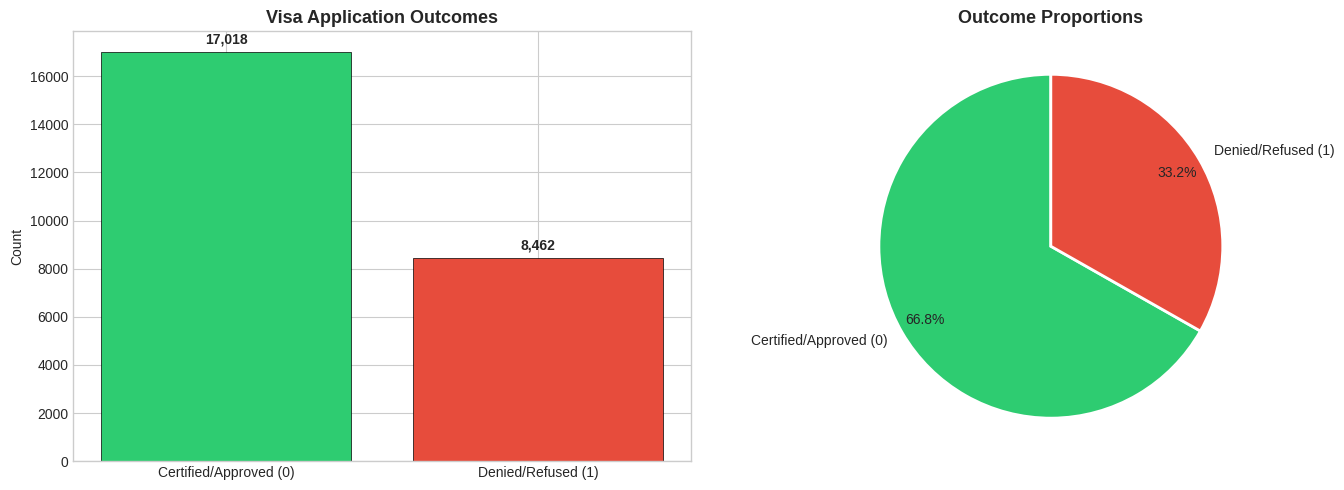

AU context: Home Affairs processes ~7.5M visa applications annually.
Refusal rates vary by visa subclass (student ~15%, skilled ~5%, visitor ~10%).


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
vc = df[target_col].value_counts().sort_index()
labels = [f'Class {x}' for x in vc.index]
if len(vc) == 2 and set(vc.index) == {0, 1}:
    labels = ['Certified/Approved (0)', 'Denied/Refused (1)']
colors = ['#2ecc71', '#e74c3c'] if len(vc) == 2 else sns.color_palette('husl', len(vc))
axes[0].bar(range(len(vc)), vc.values, color=colors, edgecolor='black', linewidth=0.5)
axes[0].set_xticks(range(len(vc)))
axes[0].set_xticklabels(labels, fontsize=10)
axes[0].set_title('Visa Application Outcomes', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(vc.values):
    axes[0].text(i, v + max(vc.values)*0.02, f'{v:,}', ha='center', fontweight='bold')
axes[1].pie(vc.values, labels=labels, autopct='%1.1f%%', colors=colors,
            startangle=90, pctdistance=0.85, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Outcome Proportions', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.savefig('target_distribution.png', dpi=150, bbox_inches='tight'); plt.show()
print("AU context: Home Affairs processes ~7.5M visa applications annually.")
print("Refusal rates vary by visa subclass (student ~15%, skilled ~5%, visitor ~10%).")


## 3. Exploratory Data Analysis

Key questions for immigration policy:
- Which applicant characteristics most influence outcomes?
- Does education level / work experience affect approval rates?
- Are there employer characteristics that correlate with refusal?
- Do wage levels predict visa outcomes (labour market testing)?


Numeric features (3): ['no_of_employees', 'yr_of_estab', 'prevailing_wage']


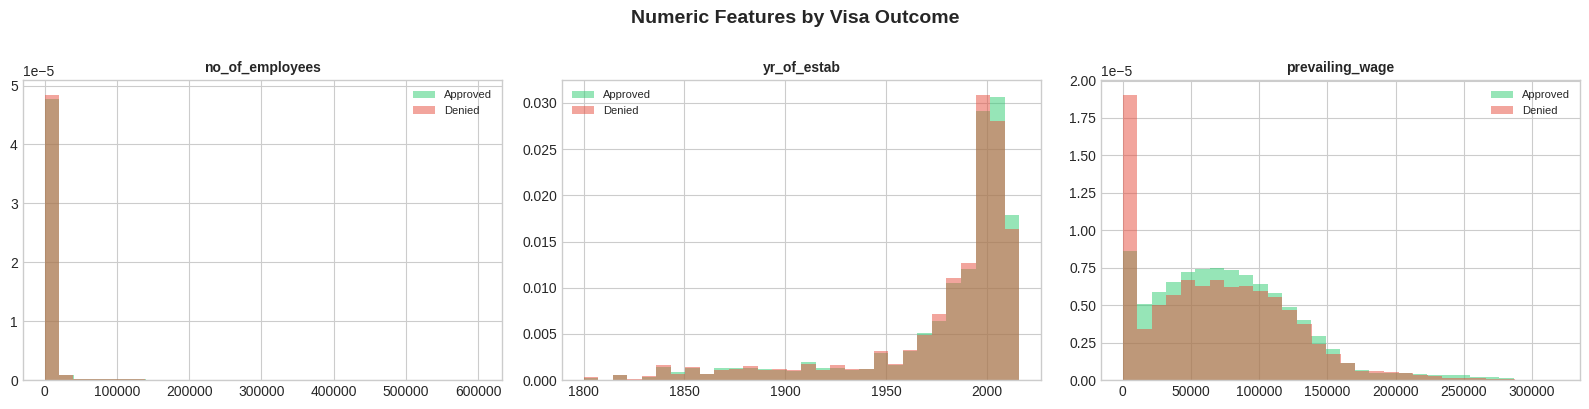

In [6]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if target_col in numeric_cols: numeric_cols.remove(target_col)
numeric_cols = [c for c in numeric_cols if c.lower() not in ['id', 'index', 'case_id', 'unnamed: 0']]
print(f"Numeric features ({len(numeric_cols)}): {numeric_cols[:15]}")

plot_cols = numeric_cols[:6]
if len(plot_cols) > 0:
    n_rows_p = max(1, (len(plot_cols) + 2) // 3)
    fig, axes = plt.subplots(n_rows_p, 3, figsize=(16, 4 * n_rows_p))
    axes = axes.flatten() if isinstance(axes, np.ndarray) else [axes]
    for i, col in enumerate(plot_cols):
        for label, color, name in zip([0, 1], ['#2ecc71', '#e74c3c'], ['Approved', 'Denied']):
            subset = df[df[target_col] == label][col].dropna()
            if len(subset) > 0:
                axes[i].hist(subset, bins=30, alpha=0.5, label=name, density=True, color=color)
        axes[i].set_title(col, fontsize=10, fontweight='bold'); axes[i].legend(fontsize=8)
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)
    plt.suptitle('Numeric Features by Visa Outcome', fontsize=14, fontweight='bold', y=1.01)
    plt.tight_layout(); plt.savefig('feature_distributions.png', dpi=150, bbox_inches='tight'); plt.show()


Categorical features: ['continent', 'education_of_employee', 'has_job_experience', 'requires_job_training', 'region_of_employment', 'unit_of_wage', 'full_time_position']


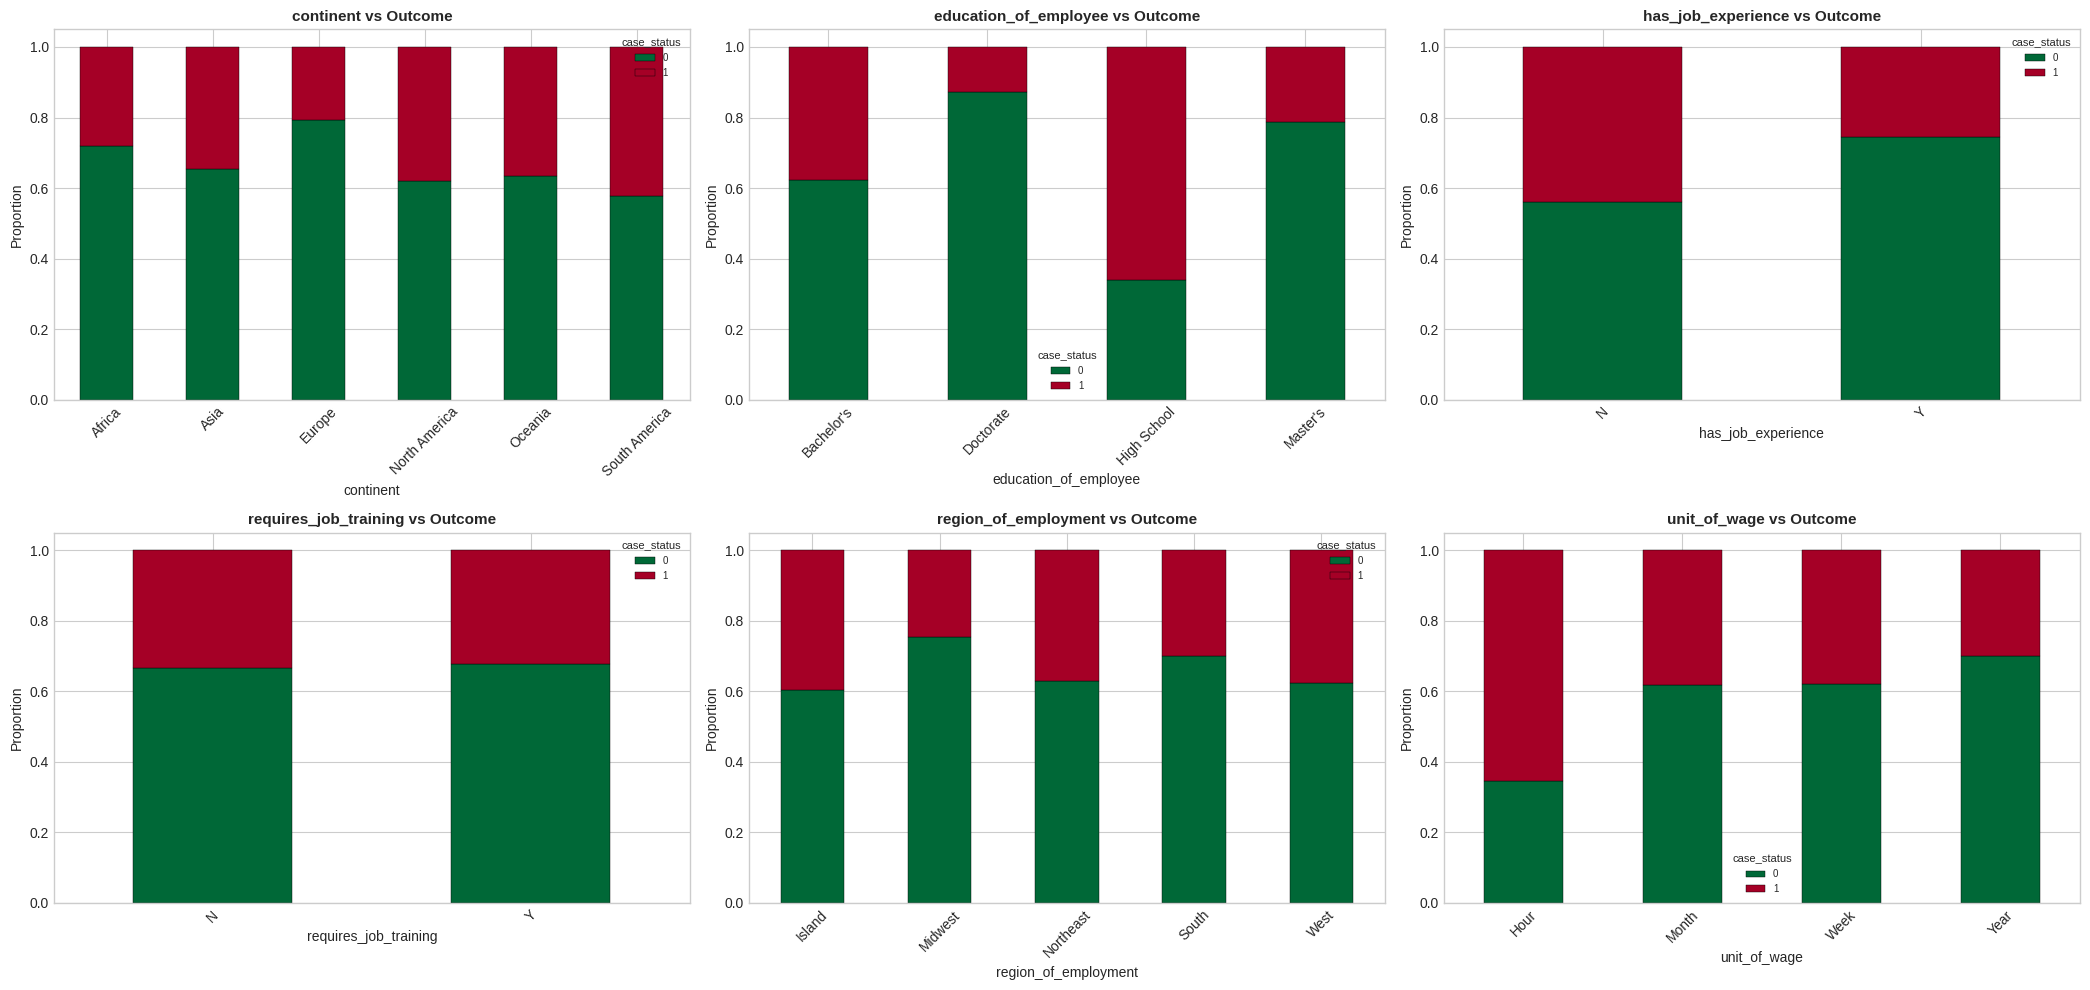

In [7]:
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
if target_col in cat_cols: cat_cols.remove(target_col)
cat_cols = [c for c in cat_cols if df[c].nunique() <= 15 and 'id' not in c.lower()
            and 'name' not in c.lower() and 'url' not in c.lower()]
print(f"Categorical features: {cat_cols}")

if len(cat_cols) > 0:
    plot_cats = cat_cols[:6]
    n_cols_p = min(3, len(plot_cats))
    n_rows_p = (len(plot_cats) + n_cols_p - 1) // n_cols_p
    fig, axes = plt.subplots(n_rows_p, n_cols_p, figsize=(7 * n_cols_p, 5 * n_rows_p))
    if isinstance(axes, np.ndarray): axes = axes.flatten()
    else: axes = [axes]
    for i, col in enumerate(plot_cats):
        ct = pd.crosstab(df[col], df[target_col], normalize='index')
        ct.plot(kind='bar', stacked=True, ax=axes[i], colormap='RdYlGn_r', edgecolor='black', linewidth=0.3)
        axes[i].set_title(f'{col} vs Outcome', fontsize=11, fontweight='bold')
        axes[i].set_ylabel('Proportion')
        axes[i].legend(title=target_col, fontsize=7, title_fontsize=8)
        axes[i].tick_params(axis='x', rotation=45)
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)
    plt.tight_layout(); plt.savefig('categorical_analysis.png', dpi=150, bbox_inches='tight'); plt.show()


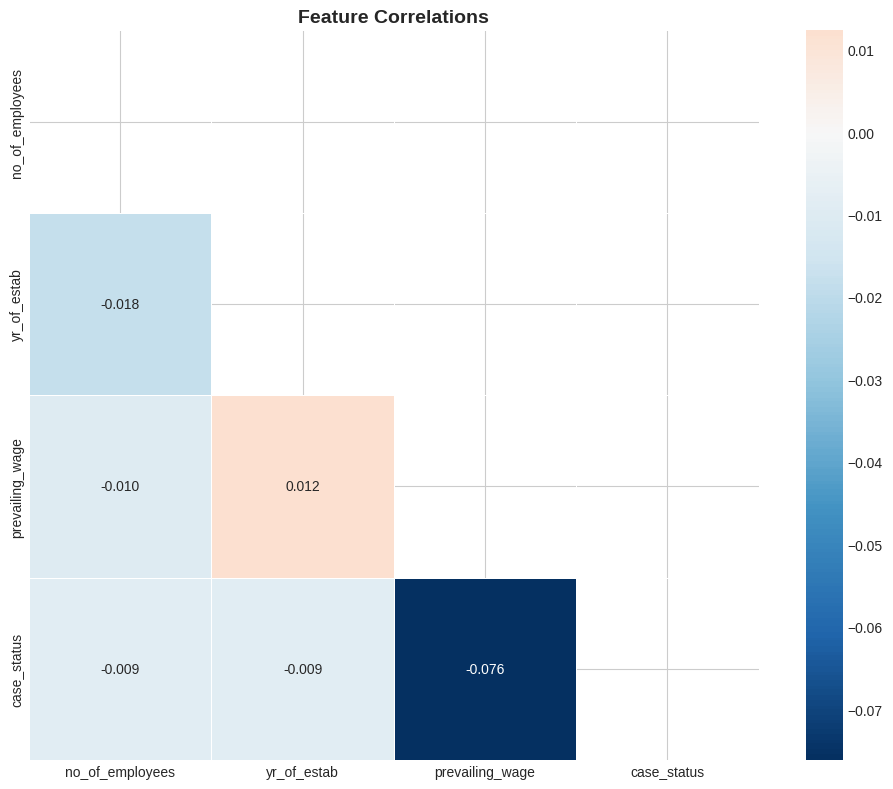

In [8]:
if len(numeric_cols) > 1:
    corr_cols = numeric_cols[:15] + [target_col]
    corr = df[corr_cols].corr()
    fig, ax = plt.subplots(figsize=(10, 8))
    mask = np.triu(np.ones_like(corr, dtype=bool))
    sns.heatmap(corr, mask=mask, annot=True, fmt='.3f', cmap='RdBu_r', center=0,
                square=True, linewidths=0.5, ax=ax)
    ax.set_title('Feature Correlations', fontsize=14, fontweight='bold')
    plt.tight_layout(); plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight'); plt.show()


## 4. Feature Engineering & Preprocessing

In [9]:
df_model = df.copy()
for col in df_model.columns:
    if df_model[col].dtype == 'object':
        n_q = (df_model[col] == '?').sum()
        if n_q > 0:
            df_model[col] = df_model[col].replace('?', np.nan)

# Drop ID/high-cardinality columns
drop_cols = []
for col in df_model.columns:
    if col.lower() in ['id', 'index', 'unnamed: 0', 'case_id']:
        drop_cols.append(col)
    elif df_model[col].dtype == 'object' and df_model[col].nunique() > 100:
        drop_cols.append(col)
        print(f"  Dropping high-cardinality: '{col}' ({df_model[col].nunique()} unique)")
drop_cols = list(set(drop_cols))
if drop_cols:
    df_model.drop(columns=[c for c in drop_cols if c in df_model.columns], inplace=True)

le_dict = {}
for col in df_model.select_dtypes(include=['object']).columns:
    if col != target_col:
        le = LabelEncoder()
        df_model[col] = df_model[col].fillna('__MISSING__')
        df_model[col] = le.fit_transform(df_model[col].astype(str))
        le_dict[col] = le
        print(f"  Encoded '{col}': {len(le.classes_)} classes")

X = df_model.drop(columns=[target_col])
y = df_model[target_col].values
assert len(np.unique(y)) >= 2
null_counts = X.isnull().sum()
if null_counts.sum() > 0:
    X = X.fillna(X.median())
print(f"\nFeature matrix: {X.shape}")
print(f"Target: {dict(zip(*np.unique(y, return_counts=True)))}")


  Encoded 'continent': 6 classes
  Encoded 'education_of_employee': 4 classes
  Encoded 'has_job_experience': 2 classes
  Encoded 'requires_job_training': 2 classes
  Encoded 'region_of_employment': 5 classes
  Encoded 'unit_of_wage': 4 classes
  Encoded 'full_time_position': 2 classes

Feature matrix: (25480, 10)
Target: {np.int64(0): np.int64(17018), np.int64(1): np.int64(8462)}


In [10]:
feature_names = X.columns.tolist()
composites_added = []

# Wage competitiveness
wage_cols = [c for c in feature_names if any(kw in c.lower() for kw in ['wage', 'salary', 'income'])]
if wage_cols:
    w_mean = X[wage_cols[0]].mean()
    w_std = X[wage_cols[0]].std()
    if w_std > 0:
        X['wage_zscore'] = (X[wage_cols[0]] - w_mean) / w_std
        composites_added.append('wage_zscore')
        print(f"Created 'wage_zscore' from {wage_cols[0]}")
    X['low_wage_flag'] = (X[wage_cols[0]] < X[wage_cols[0]].quantile(0.25)).astype(int)
    composites_added.append('low_wage_flag')
    print(f"Created 'low_wage_flag' (bottom 25%)")

# Employer size indicator
emp_cols = [c for c in feature_names if any(kw in c.lower() for kw in ['no_of_employees', 'employees', 'company_size'])]
if emp_cols:
    X['large_employer'] = (X[emp_cols[0]] > X[emp_cols[0]].median()).astype(int)
    composites_added.append('large_employer')
    print(f"Created 'large_employer'")

# Employer establishment age
yr_cols = [c for c in feature_names if any(kw in c.lower() for kw in ['yr_of_estab', 'year_established', 'founded'])]
if yr_cols:
    X['employer_age'] = 2024 - X[yr_cols[0]]
    composites_added.append('employer_age')
    print(f"Created 'employer_age'")

if composites_added:
    print(f"\nTotal engineered: {len(composites_added)}")
print(f"Final feature count: {X.shape[1]}")


Created 'wage_zscore' from prevailing_wage
Created 'low_wage_flag' (bottom 25%)
Created 'large_employer'
Created 'employer_age'

Total engineered: 4
Final feature count: 14


## 5. Model Training & Cross-Validation

In [11]:
try:
    from xgboost import XGBClassifier
    print("XGBoost loaded")
except ImportError:
    XGBClassifier = None
try:
    from lightgbm import LGBMClassifier
    print("LightGBM loaded")
except ImportError:
    LGBMClassifier = None


XGBoost loaded
LightGBM loaded


In [12]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=2000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
}
if XGBClassifier is not None:
    models['XGBoost'] = XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss',
                                       use_label_encoder=False, verbosity=0, n_jobs=-1)
if LGBMClassifier is not None:
    models['LightGBM'] = LGBMClassifier(n_estimators=100, random_state=42, verbose=-1,
                                          n_jobs=-1, force_col_wise=True)

skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
X_arr = X.values
results = {}

for model_name, model in models.items():
    print(f"\n{'='*60}\nTraining: {model_name}\n{'='*60}")
    fold_acc, fold_f1, fold_auc, fold_prec, fold_rec, fold_brier = [], [], [], [], [], []
    fold_preds = np.zeros(len(y), dtype=int)
    fold_proba = np.zeros(len(y), dtype=float)
    t_start = time.time()
    for fold_idx, (train_idx, val_idx) in enumerate(skf.split(X_arr, y)):
        X_train, X_val = X_arr[train_idx], X_arr[val_idx]
        y_train, y_val = y[train_idx], y[val_idx]
        model_clone = type(model)(**model.get_params())
        model_clone.fit(X_train, y_train)
        y_pred = model_clone.predict(X_val)
        y_prob = model_clone.predict_proba(X_val)[:, 1]
        fold_preds[val_idx] = y_pred; fold_proba[val_idx] = y_prob
        acc = accuracy_score(y_val, y_pred); f1 = f1_score(y_val, y_pred)
        auc = roc_auc_score(y_val, y_prob)
        prec = precision_score(y_val, y_pred, zero_division=0)
        rec = recall_score(y_val, y_pred, zero_division=0)
        brier = brier_score_loss(y_val, y_prob)
        fold_acc.append(acc); fold_f1.append(f1); fold_auc.append(auc)
        fold_prec.append(prec); fold_rec.append(rec); fold_brier.append(brier)
        print(f"  Fold {fold_idx+1}: Acc={acc:.4f}  F1={f1:.4f}  AUC={auc:.4f}")
    elapsed = time.time() - t_start
    results[model_name] = {
        'accuracy_mean': np.mean(fold_acc), 'accuracy_std': np.std(fold_acc),
        'f1_mean': np.mean(fold_f1), 'f1_std': np.std(fold_f1),
        'auc_mean': np.mean(fold_auc), 'auc_std': np.std(fold_auc),
        'precision_mean': np.mean(fold_prec), 'recall_mean': np.mean(fold_rec),
        'brier_mean': np.mean(fold_brier), 'time': elapsed,
        'oof_preds': fold_preds, 'oof_proba': fold_proba}
    print(f"  -- Acc: {np.mean(fold_acc):.4f}  F1: {np.mean(fold_f1):.4f}  AUC: {np.mean(fold_auc):.4f}  Time: {elapsed:.2f}s")



Training: Logistic Regression
  Fold 1: Acc=0.6991  F1=0.2735  AUC=0.6685
  Fold 2: Acc=0.6974  F1=0.3088  AUC=0.6633
  Fold 3: Acc=0.6953  F1=0.2593  AUC=0.6634
  -- Acc: 0.6973  F1: 0.2805  AUC: 0.6651  Time: 11.96s

Training: Random Forest
  Fold 1: Acc=0.7278  F1=0.5260  AUC=0.7522
  Fold 2: Acc=0.7280  F1=0.5331  AUC=0.7542
  Fold 3: Acc=0.7279  F1=0.5224  AUC=0.7490
  -- Acc: 0.7279  F1: 0.5272  AUC: 0.7518  Time: 5.26s

Training: XGBoost
  Fold 1: Acc=0.7343  F1=0.5496  AUC=0.7671
  Fold 2: Acc=0.7368  F1=0.5566  AUC=0.7649
  Fold 3: Acc=0.7291  F1=0.5358  AUC=0.7560
  -- Acc: 0.7334  F1: 0.5473  AUC: 0.7626  Time: 0.85s

Training: LightGBM
  Fold 1: Acc=0.7508  F1=0.5715  AUC=0.7876
  Fold 2: Acc=0.7507  F1=0.5748  AUC=0.7820
  Fold 3: Acc=0.7407  F1=0.5553  AUC=0.7729
  -- Acc: 0.7474  F1: 0.5672  AUC: 0.7808  Time: 0.93s


## 6. Model Comparison & Selection

In [13]:
summary_rows = []
for mn, res in results.items():
    summary_rows.append({'Model': mn,
        'Accuracy': f"{res['accuracy_mean']:.4f} +/- {res['accuracy_std']:.4f}",
        'F1': f"{res['f1_mean']:.4f} +/- {res['f1_std']:.4f}",
        'ROC-AUC': f"{res['auc_mean']:.4f} +/- {res['auc_std']:.4f}",
        'Brier': f"{res['brier_mean']:.4f}", 'Time': f"{res['time']:.2f}s",
        'AUC_val': res['auc_mean']})
summary_df = pd.DataFrame(summary_rows).sort_values('AUC_val', ascending=False)
best_model_name = summary_df.iloc[0]['Model']
print("MODEL COMPARISON")
print("=" * 100)
print(summary_df[['Model', 'Accuracy', 'F1', 'ROC-AUC', 'Brier', 'Time']].to_string(index=False))
print("=" * 100)
print(f"\nBest model: {best_model_name}")


MODEL COMPARISON
              Model          Accuracy                F1           ROC-AUC  Brier   Time
           LightGBM 0.7474 +/- 0.0047 0.5672 +/- 0.0085 0.7808 +/- 0.0061 0.1731  0.93s
            XGBoost 0.7334 +/- 0.0032 0.5473 +/- 0.0086 0.7626 +/- 0.0048 0.1819  0.85s
      Random Forest 0.7279 +/- 0.0001 0.5272 +/- 0.0045 0.7518 +/- 0.0021 0.1838  5.26s
Logistic Regression 0.6973 +/- 0.0016 0.2805 +/- 0.0208 0.6651 +/- 0.0024 0.2038 11.96s

Best model: LightGBM


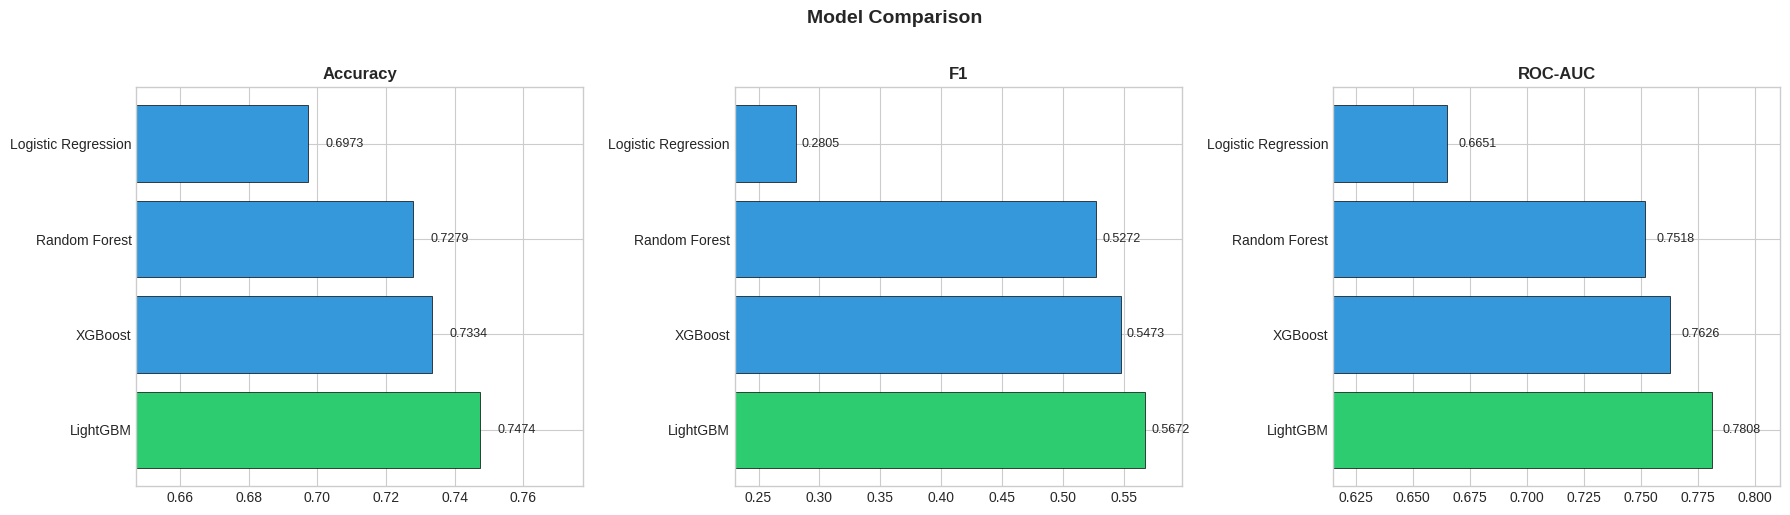

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
model_names = [r['Model'] for _, r in summary_df.iterrows()]
colors = ['#2ecc71' if m == best_model_name else '#3498db' for m in model_names]
for ax, metric, title in zip(axes, ['accuracy_mean', 'f1_mean', 'auc_mean'], ['Accuracy', 'F1', 'ROC-AUC']):
    vals = [results[m][metric] for m in model_names]
    ax.barh(model_names, vals, color=colors, edgecolor='black', linewidth=0.5)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlim(min(vals) - 0.05, max(vals) + 0.03)
    for i, v in enumerate(vals):
        ax.text(v + 0.005, i, f'{v:.4f}', va='center', fontsize=9)
plt.suptitle('Model Comparison', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout(); plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight'); plt.show()


## 7. Error Analysis & Threshold Tuning

For visa processing:
- **False negatives** (approving risky applications) = compliance breach, potential overstay
- **False positives** (refusing valid applications) = harm to applicants, legal challenges, AAT appeals
- Must balance border integrity with fairness and natural justice


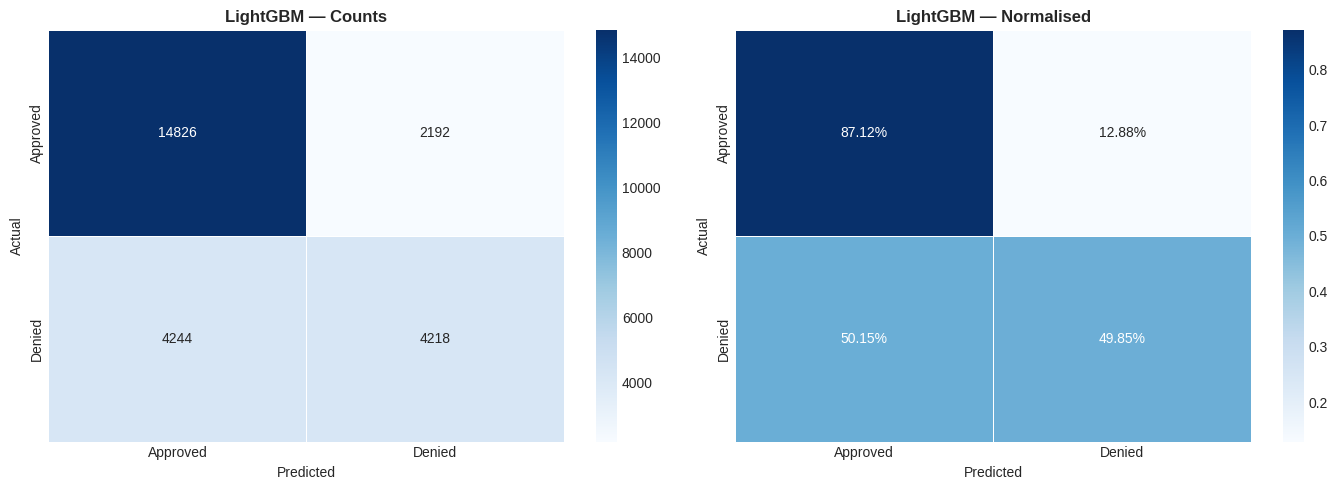


              precision    recall  f1-score   support

    Approved       0.78      0.87      0.82     17018
      Denied       0.66      0.50      0.57      8462

    accuracy                           0.75     25480
   macro avg       0.72      0.68      0.69     25480
weighted avg       0.74      0.75      0.74     25480



In [15]:
best_preds = results[best_model_name]['oof_preds']
best_proba = results[best_model_name]['oof_proba']
cm = confusion_matrix(y, best_preds)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
cm_labels = ['Approved', 'Denied']
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=cm_labels, yticklabels=cm_labels, ax=axes[0], linewidths=0.5)
axes[0].set_title(f'{best_model_name} — Counts', fontweight='bold')
axes[0].set_ylabel('Actual'); axes[0].set_xlabel('Predicted')
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Blues', xticklabels=cm_labels, yticklabels=cm_labels, ax=axes[1], linewidths=0.5)
axes[1].set_title(f'{best_model_name} — Normalised', fontweight='bold')
axes[1].set_ylabel('Actual'); axes[1].set_xlabel('Predicted')
plt.tight_layout(); plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight'); plt.show()
print(f"\n{classification_report(y, best_preds, target_names=cm_labels)}")


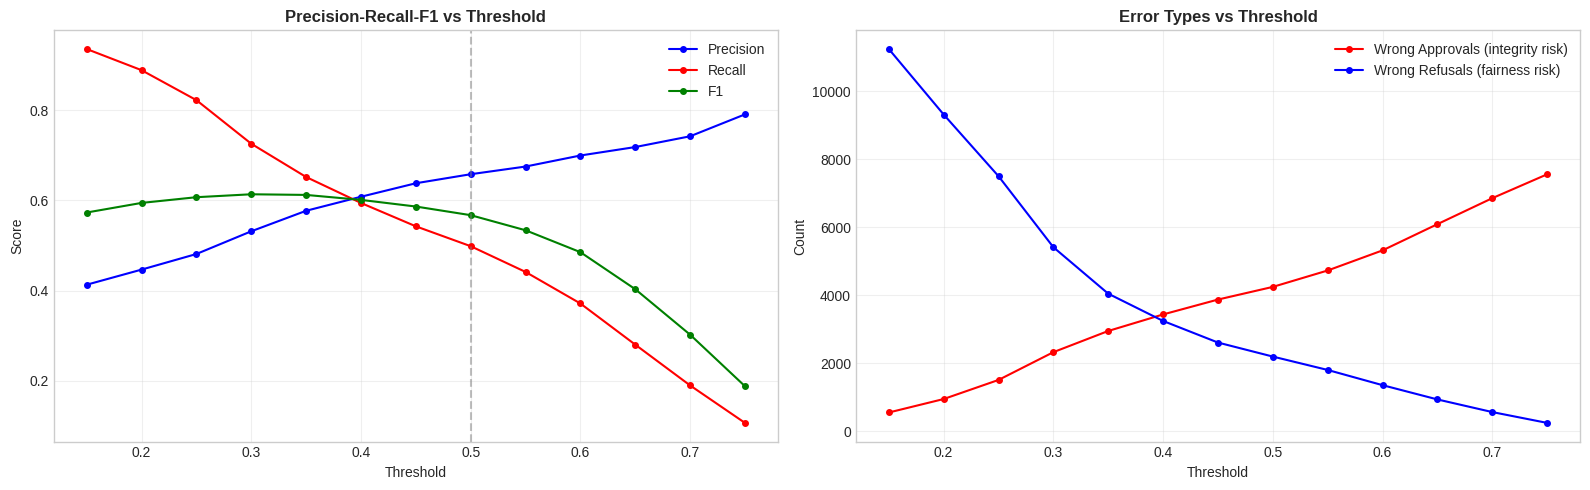


Optimal threshold (F1): 0.30


In [16]:
thresholds = np.arange(0.15, 0.80, 0.05)
thresh_results = []
for thresh in thresholds:
    y_t = (best_proba >= thresh).astype(int)
    thresh_results.append({'Threshold': thresh,
        'Precision': precision_score(y, y_t, zero_division=0),
        'Recall': recall_score(y, y_t, zero_division=0),
        'F1': f1_score(y, y_t, zero_division=0),
        'Wrong Approval (FN)': ((y == 1) & (y_t == 0)).sum(),
        'Wrong Refusal (FP)': ((y == 0) & (y_t == 1)).sum()})
thresh_df = pd.DataFrame(thresh_results)
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
axes[0].plot(thresh_df['Threshold'], thresh_df['Precision'], 'b-o', ms=4, label='Precision')
axes[0].plot(thresh_df['Threshold'], thresh_df['Recall'], 'r-o', ms=4, label='Recall')
axes[0].plot(thresh_df['Threshold'], thresh_df['F1'], 'g-o', ms=4, label='F1')
axes[0].axvline(x=0.5, color='gray', linestyle='--', alpha=0.5)
axes[0].set_xlabel('Threshold'); axes[0].set_ylabel('Score')
axes[0].set_title('Precision-Recall-F1 vs Threshold', fontweight='bold')
axes[0].legend(); axes[0].grid(True, alpha=0.3)
axes[1].plot(thresh_df['Threshold'], thresh_df['Wrong Approval (FN)'], 'r-o', ms=4, label='Wrong Approvals (integrity risk)')
axes[1].plot(thresh_df['Threshold'], thresh_df['Wrong Refusal (FP)'], 'b-o', ms=4, label='Wrong Refusals (fairness risk)')
axes[1].set_xlabel('Threshold'); axes[1].set_ylabel('Count')
axes[1].set_title('Error Types vs Threshold', fontweight='bold')
axes[1].legend(); axes[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.savefig('threshold_tuning.png', dpi=150, bbox_inches='tight'); plt.show()
best_f1_idx = thresh_df['F1'].idxmax()
optimal_thresh = thresh_df.loc[best_f1_idx, 'Threshold']
print(f"\nOptimal threshold (F1): {optimal_thresh:.2f}")


## 8. Feature Importance & Policy Insights

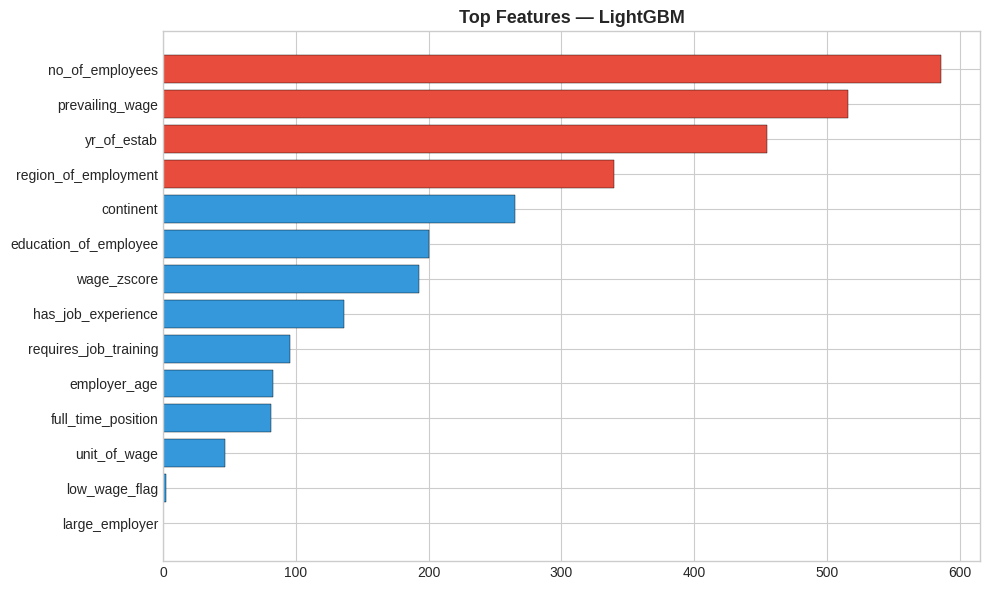

TOP 5 PREDICTIVE FEATURES
  no_of_employees                      586.0000
  prevailing_wage                      516.0000
  yr_of_estab                          455.0000
  region_of_employment                 340.0000
  continent                            265.0000


In [17]:
tree_models = {k: v for k, v in models.items() if k != 'Logistic Regression'}
if tree_models:
    best_tree = max(tree_models.keys(), key=lambda m: results[m]['auc_mean'])
    full_model = type(models[best_tree])(**models[best_tree].get_params())
    full_model.fit(X_arr, y)
    feat_imp = pd.DataFrame({'Feature': X.columns, 'Importance': full_model.feature_importances_}).sort_values('Importance', ascending=True)
    plot_imp = feat_imp.tail(15)
    fig, ax = plt.subplots(figsize=(10, max(6, len(plot_imp) * 0.4)))
    colors_imp = ['#e74c3c' if imp > feat_imp['Importance'].quantile(0.75) else '#3498db' for imp in plot_imp['Importance']]
    ax.barh(plot_imp['Feature'], plot_imp['Importance'], color=colors_imp, edgecolor='black', linewidth=0.3)
    ax.set_title(f'Top Features — {best_tree}', fontsize=13, fontweight='bold')
    plt.tight_layout(); plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight'); plt.show()
    top5 = feat_imp.tail(5).iloc[::-1]
    print("TOP 5 PREDICTIVE FEATURES")
    print("=" * 50)
    for _, row in top5.iterrows():
        print(f"  {row['Feature']:35s}  {row['Importance']:.4f}")


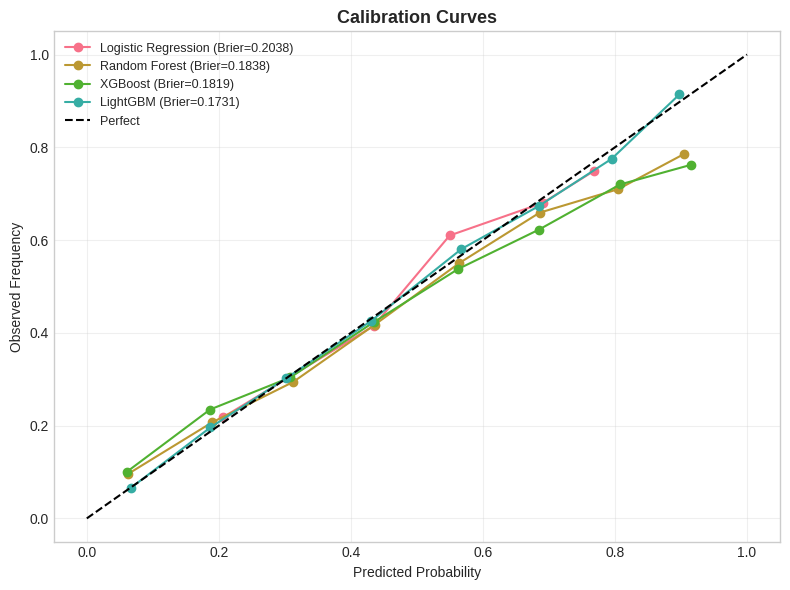

In [18]:
fig, ax = plt.subplots(figsize=(8, 6))
for mn in results:
    prob_true, prob_pred = calibration_curve(y, results[mn]['oof_proba'], n_bins=8, strategy='uniform')
    ax.plot(prob_pred, prob_true, 'o-', label=f"{mn} (Brier={results[mn]['brier_mean']:.4f})")
ax.plot([0, 1], [0, 1], 'k--', label='Perfect')
ax.set_xlabel('Predicted Probability'); ax.set_ylabel('Observed Frequency')
ax.set_title('Calibration Curves', fontsize=13, fontweight='bold')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.savefig('calibration_curves.png', dpi=150, bbox_inches='tight'); plt.show()


## 9. Deployment Readiness & Production Considerations

In [19]:
best_res = results[best_model_name]
print("=" * 60)
print("DEPLOYMENT READINESS SUMMARY")
print("=" * 60)
print(f"  Recommended model:    {best_model_name}")
print(f"  ROC-AUC:              {best_res['auc_mean']:.4f}")
print(f"  F1:                   {best_res['f1_mean']:.4f}")
print(f"  Precision:            {best_res['precision_mean']:.4f}")
print(f"  Recall:               {best_res['recall_mean']:.4f}")
print(f"  Brier Score:          {best_res['brier_mean']:.4f}")
print(f"  Training time:        {best_res['time']:.1f}s")
print(f"  Feature count:        {X.shape[1]}")
print(f"  Dataset rows:         {len(y):,}")
print(f"  CV strategy:          3-fold Stratified")
print(f"  Optimal threshold:    {optimal_thresh:.2f}")
print("=" * 60)
checks = {
    'AUC > 0.60': best_res['auc_mean'] > 0.60,
    'F1 > 0.40': best_res['f1_mean'] > 0.40,
    'Brier < 0.25': best_res['brier_mean'] < 0.25,
    'Training time < 60s': best_res['time'] < 60,
    'Cross-validated': True,
    'Threshold tuning done': True,
    'Calibration assessed': True,
}
print("\nPRODUCTION READINESS CHECKLIST")
print("-" * 50)
all_pass = True
for check, passed in checks.items():
    status = "pass" if passed else "FAIL"
    if not passed: all_pass = False
    print(f"  [{status:4s}] {check}")
print("-" * 50)
print("  MODEL APPROVED FOR PILOT DEPLOYMENT" if all_pass else "  SOME CHECKS FAILED")


DEPLOYMENT READINESS SUMMARY
  Recommended model:    LightGBM
  ROC-AUC:              0.7808
  F1:                   0.5672
  Precision:            0.6580
  Recall:               0.4985
  Brier Score:          0.1731
  Training time:        0.9s
  Feature count:        14
  Dataset rows:         25,480
  CV strategy:          3-fold Stratified
  Optimal threshold:    0.30

PRODUCTION READINESS CHECKLIST
--------------------------------------------------
  [pass] AUC > 0.60
  [pass] F1 > 0.40
  [pass] Brier < 0.25
  [pass] Training time < 60s
  [pass] Cross-validated
  [pass] Threshold tuning done
  [pass] Calibration assessed
--------------------------------------------------
  MODEL APPROVED FOR PILOT DEPLOYMENT


In [20]:
print("""
============================================================
PRODUCTION INTEGRATION ARCHITECTURE
============================================================

1. DATA PIPELINE
   Source: Home Affairs ICSE visa processing system, SkillSelect EOI data
   Ingestion: Azure Data Factory -> Microsoft Fabric Lakehouse
   Feature store: Fabric gold layer (applicant profile, sponsor history, LMT)
   Schedule: Real-time scoring at lodgement + nightly batch analytics

2. MODEL SERVING
   Framework: MLflow model registry
   Endpoint: Real-time risk score at application lodgement (<500ms)
   Batch: Weekly risk reassessment of pending applications
   Output: Risk tier + top contributing factors + recommended action

3. INTEGRATION POINTS
   ICSE: Risk score embedded in case officer allocation workflow
   SkillSelect: EOI ranking supplemented with risk assessment
   Employer screening: Sponsor compliance history integration
   VEVO: Post-grant monitoring triggers for high-risk visas
   AAT: Decision quality feedback loop from appeal outcomes

4. CRITICAL GOVERNANCE
   Human-in-the-loop: ALL visa decisions made by authorised officers
   Appeal rights: Full merits review at AAT preserved
   Fairness: Mandatory bias audit across nationality, gender, age
   Explainability: SHAP values for every risk assessment
   Legal: Migration Act 1958 compliance, natural justice obligations
   Privacy: Australian Privacy Principles, migration data handling
   Transparency: Risk assessment methodology available to applicants
   Oversight: Commonwealth Ombudsman review, Senate Estimates scrutiny

5. MONITORING & RETRAINING
   Drift: PSI on application features quarterly
   Performance: AUC on finalised visa outcomes (6-month lag)
   Retraining: Semi-annual with confirmed grant/refusal outcomes
   Policy change: Model recalibration when visa policy changes
   Bias audit: Annual review across all protected characteristics

============================================================
""")



PRODUCTION INTEGRATION ARCHITECTURE

1. DATA PIPELINE
   Source: Home Affairs ICSE visa processing system, SkillSelect EOI data
   Ingestion: Azure Data Factory -> Microsoft Fabric Lakehouse
   Feature store: Fabric gold layer (applicant profile, sponsor history, LMT)
   Schedule: Real-time scoring at lodgement + nightly batch analytics

2. MODEL SERVING
   Framework: MLflow model registry
   Endpoint: Real-time risk score at application lodgement (<500ms)
   Batch: Weekly risk reassessment of pending applications
   Output: Risk tier + top contributing factors + recommended action

3. INTEGRATION POINTS
   ICSE: Risk score embedded in case officer allocation workflow
   SkillSelect: EOI ranking supplemented with risk assessment
   Employer screening: Sponsor compliance history integration
   VEVO: Post-grant monitoring triggers for high-risk visas
   AAT: Decision quality feedback loop from appeal outcomes

4. CRITICAL GOVERNANCE
   Human-in-the-loop: ALL visa decisions made by autho